# 🚗 Modelo de Riesgo de Accidente de Tráfico — Medellín
## Probabilidad de Accidente por Hora, Barrio y Día

---

### 🎯 Objetivo del Proyecto

Construir un modelo de machine learning que prediga la probabilidad de que ocurra al menos un accidente
de tráfico en una ubicación específica, un día de la semana y una franja horaria determinada.

### 📦 Datos de entrada

- **Fuente:** Registros administrativos de incidentes de tráfico en Medellín, Colombia
- **Período:** 2008-01-01 a 2025-08-31
- **Volumen:** Aproximadamente 700,000 registros
- **Formato:** Archivo Excel (`Fatal_Road_Traffic.xlsx`)

### 🧩 Estrategia de modelado

El dataset original solo contiene registros donde **sí ocurrió un accidente** (eventos positivos).
Para entrenar un modelo de clasificación necesitamos también ejemplos de **no accidentes** (eventos negativos).

**Enfoque:**
1. Crear una grilla con todas las combinaciones posibles de ubicación × día × franja horaria × mes
2. Las combinaciones que aparecen en el dataset original → etiqueta **1** (hubo accidente)
3. Las combinaciones que no aparecen → etiqueta **0** (no hubo accidente en ese slot)
4. Entrenar modelos de clasificación para distinguir condiciones de riesgo

### 🗑️ Política de manejo de nulos

Para garantizar la calidad de los datos de entrenamiento, **eliminaremos todos los registros**
que contengan valores nulos en cualquiera de las columnas críticas para el modelo:
- Fecha del incidente
- Hora del incidente
- Ubicación (barrio o comuna)

Esto asegura que cada muestra en nuestro dataset tenga información completa y confiable.

---
## Paso 0: Configuración del entorno

Importamos todas las librerías necesarias y configuramos los parámetros globales
de visualización y rendimiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import xgboost as xgb

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


In [13]:
import os

file_path = '/content/data/Fatal_Road_Traffic.xlsx'

if os.path.exists(file_path):
    file_size_bytes = os.path.getsize(file_path)

    # Convertir a un formato más legible (KB, MB, GB)
    if file_size_bytes < 1024:
        size_str = f"{file_size_bytes} bytes"
    elif file_size_bytes < (1024**2):
        size_str = f"{file_size_bytes / 1024:.2f} KB"
    elif file_size_bytes < (1024**3):
        size_str = f"{file_size_bytes / (1024**2):.2f} MB"
    else:
        size_str = f"{file_size_bytes / (1024**3):.2f} GB"

    print(f"El tamaño del archivo '{file_path}' es: {size_str}")
else:
    print(f"Error: El archivo '{file_path}' no fue encontrado.")

El tamaño del archivo '/content/data/Fatal_Road_Traffic.xlsx' es: 60.42 MB


In [14]:
dtype_dict = {
    'LLAVE': 'int32',
    'AÑO': 'int16',
    'CLASE_INCIDENTE': 'category',
    'GRAVEDAD_INCIDENTE': 'category',
    'Codigo Comuna Planeacion': 'str',
    'Comuna Planeacion': 'category',
    'Codigo Barrio Planeacion': 'str',
    'Barrio Planeacion': 'str',
    'Latitud': 'float32',
    'Longitud': 'float32'
}

columnas_necesarias = [
    'LLAVE', 'AÑO', 'FECHA_INCIDENTE', 'HORA_INCIDENTE',
    'CLASE_INCIDENTE', 'GRAVEDAD_INCIDENTE',
    'Codigo Comuna Planeacion', 'Comuna Planeacion',
    'Codigo Barrio Planeacion', 'Barrio Planeacion'
]

print("⏳ Cargando dataset (~700,000 registros)...")

df = pd.read_excel(
    '/content/data/Fatal_Road_Traffic.xlsx',
    sheet_name='BD',
    dtype=dtype_dict,
    usecols=columnas_necesarias
)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📊 Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"📅 Período: {df['AÑO'].min()} - {df['AÑO'].max()}")

⏳ Cargando dataset (~700,000 registros)...
✅ Dataset cargado: 702,540 filas × 10 columnas
📊 Memoria usada: 156.2 MB
📅 Período: 2008 - 2025


---
## Paso 1: Carga del dataset

Cargamos el archivo Excel con los registros de incidentes. Para manejar eficientemente
los ~700,000 registros, especificamos tipos de datos optimizados y solo cargamos las
columnas necesarias para el modelo.

**Columnas relevantes:**
- `LLAVE`: Identificador único del incidente
- `FECHA_INCIDENTE`: Fecha en que ocurrió el evento
- `HORA_INCIDENTE`: Hora del evento (formato HH:MM:SS o HH:MM)
- `Comuna Planeacion`: Nombre de la comuna
- `Barrio Planeacion`: Nombre del barrio

---
## Paso 2: Diagnóstico de valores nulos

Antes de eliminar registros, realizamos un diagnóstico completo para entender
la magnitud y distribución de los datos faltantes. Esto nos permite tomar
decisiones informadas sobre qué eliminar y documentar el impacto.

In [15]:
print("🔍 DIAGNÓSTICO DE VALORES NULOS")
print("=" * 70)

nulos_df = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print(nulos_df.to_string(index=False))

print(f"\n📊 Total de registros antes de limpieza: {len(df):,}")

🔍 DIAGNÓSTICO DE VALORES NULOS
                 Columna  Nulos  Porcentaje
       Barrio Planeacion  11683      1.6600
Codigo Barrio Planeacion  11683      1.6600
                     AÑO      0      0.0000
                   LLAVE      0      0.0000
         FECHA_INCIDENTE      0      0.0000
          HORA_INCIDENTE      0      0.0000
      GRAVEDAD_INCIDENTE      0      0.0000
         CLASE_INCIDENTE      0      0.0000
       Comuna Planeacion      0      0.0000
Codigo Comuna Planeacion      0      0.0000

📊 Total de registros antes de limpieza: 702,540


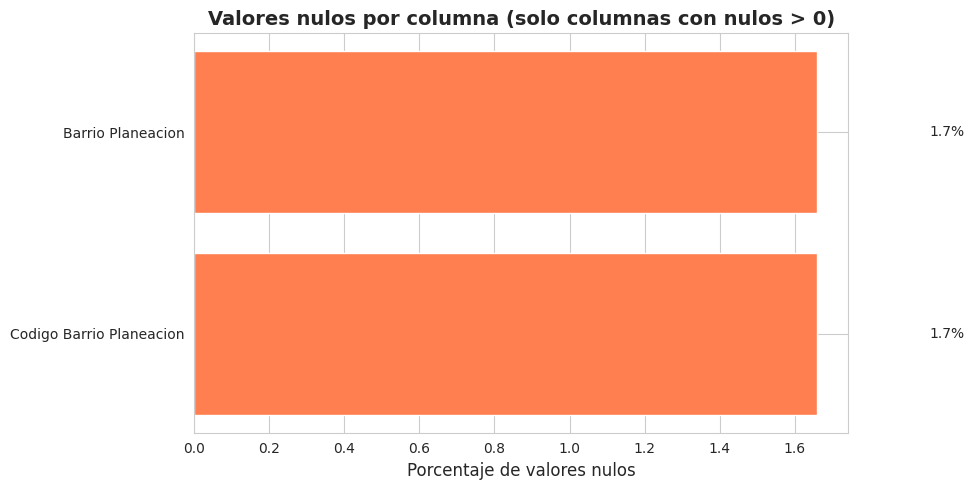

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

nulos_plot = nulos_df[nulos_df['Nulos'] > 0]
bars = ax.barh(nulos_plot['Columna'], nulos_plot['Porcentaje'], color='coral', edgecolor='white')
ax.set_xlabel('Porcentaje de valores nulos', fontsize=12)
ax.set_title('Valores nulos por columna (solo columnas con nulos > 0)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, pct in zip(bars, nulos_plot['Porcentaje']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Paso 3: Limpieza de datos — Eliminación de nulos

Nuestra política es clara: **eliminar cualquier registro que tenga valores nulos**
en las columnas críticas para el modelo.

**Columnas críticas:**
1. `FECHA_INCIDENTE` — Sin fecha no podemos ubicar temporalmente el evento
2. `HORA_INCIDENTE` — Sin hora no podemos asignar franja horaria
3. `Comuna Planeacion` — Sin ubicación no podemos hacer análisis espacial
4. `Barrio Planeacion` — Complemento de ubicación, pero usaremos Comuna si Barrio falta

**Estrategia para ubicación:**
- Si el barrio es `"Sin inf"` o nulo → usamos la comuna como identificador de ubicación
- Si la comuna también es `"N/D"` o nula → eliminamos el registro

Esta estrategia maximiza la retención de datos mientras garantiza integridad.

In [17]:
registros_iniciales = len(df)

df['FECHA_INCIDENTE'] = pd.to_datetime(df['FECHA_INCIDENTE'], errors='coerce')

df = df.dropna(subset=['FECHA_INCIDENTE'])
perdidos_fecha = registros_iniciales - len(df)

print(f"Registros eliminados por fecha inválida: {perdidos_fecha}")
print(f"Registros restantes: {len(df):,}")

Registros eliminados por fecha inválida: 0
Registros restantes: 702,540


In [18]:
df['HORA_NUM'] = pd.to_datetime(
    df['HORA_INCIDENTE'], format='%H:%M:%S', errors='coerce'
).dt.hour

mask_nan_hora = df['HORA_NUM'].isna()
df.loc[mask_nan_hora, 'HORA_NUM'] = pd.to_datetime(
    df.loc[mask_nan_hora, 'HORA_INCIDENTE'],
    format='%H:%M', errors='coerce'
).dt.hour

perdidos_hora = df['HORA_NUM'].isna().sum()
df = df.dropna(subset=['HORA_NUM'])
df['HORA_NUM'] = df['HORA_NUM'].astype('int8')

print(f"Registros eliminados por hora inválida: {perdidos_hora}")
print(f"Registros restantes: {len(df):,}")

Registros eliminados por hora inválida: 0
Registros restantes: 702,540


In [19]:
df['UBICACION_KEY'] = df['Barrio Planeacion'].copy()

mask_sin_barrio = (df['UBICACION_KEY'] == 'Sin inf') | (df['UBICACION_KEY'].isna())
df.loc[mask_sin_barrio, 'UBICACION_KEY'] = df.loc[mask_sin_barrio, 'Comuna Planeacion']

mask_sin_ubicacion = (
    (df['UBICACION_KEY'] == 'N/D') |
    (df['UBICACION_KEY'].isna()) |
    (df['UBICACION_KEY'] == 'Sin inf')
)

perdidos_ubicacion = mask_sin_ubicacion.sum()
df = df[~mask_sin_ubicacion]

print(f"Registros eliminados por ubicación desconocida: {perdidos_ubicacion}")
print(f"Registros restantes: {len(df):,}")
print(f"Ubicaciones únicas finales: {df['UBICACION_KEY'].nunique()}")

Registros eliminados por ubicación desconocida: 28146
Registros restantes: 674,394
Ubicaciones únicas finales: 402


In [20]:
total_eliminados = registros_iniciales - len(df)

print("\n" + "=" * 70)
print("📊 RESUMEN DE LIMPIEZA")
print("=" * 70)
print(f"Registros iniciales:        {registros_iniciales:>10,}")
print(f"Registros eliminados:       {total_eliminados:>10,} ({total_eliminados/registros_iniciales*100:.1f}%)")
print(f"Registros finales válidos:  {len(df):>10,} ({len(df)/registros_iniciales*100:.1f}%)")

del mask_nan_hora, mask_sin_barrio, mask_sin_ubicacion
gc.collect()

print("\n✅ Limpieza completada — Dataset listo para feature engineering")


📊 RESUMEN DE LIMPIEZA
Registros iniciales:           702,540
Registros eliminados:           28,146 (4.0%)
Registros finales válidos:     674,394 (96.0%)

✅ Limpieza completada — Dataset listo para feature engineering


---
## Paso 4: Feature Engineering temporal

Creamos variables derivadas de la fecha y hora que capturan patrones temporales:

| Feature | Descripción | Tipo |
|---------|-------------|------|
| `DIA_SEMANA` | 0=Lunes ... 6=Domingo | int |
| `DIA_NOMBRE` | Nombre del día | str |
| `ES_FIN_SEMANA` | 1 si es sábado o domingo | binario |
| `MES` | 1-12 | int |
| `FRANJA_HORARIA` | Madrugada/Mañana/Tarde/Noche | categórica |
| `FRANJA_2H` | Franjas de 2 horas (00-02h, 02-04h, ...) | categórica |

Las franjas de 2 horas ofrecen un buen balance entre granularidad y densidad de datos.

In [21]:
df['DIA_SEMANA'] = df['FECHA_INCIDENTE'].dt.dayofweek.astype('int8')

dias_nombre = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['DIA_NOMBRE'] = df['DIA_SEMANA'].map(lambda x: dias_nombre[x])

df['ES_FIN_SEMANA'] = df['DIA_SEMANA'].isin([5, 6]).astype('int8')

df['MES'] = df['FECHA_INCIDENTE'].dt.month.astype('int8')

bins_hora = [0, 6, 12, 18, 24]
labels_hora = ['Madrugada (0-5)', 'Mañana (6-11)', 'Tarde (12-17)', 'Noche (18-23)']
df['FRANJA_HORARIA'] = pd.cut(
    df['HORA_NUM'], bins=bins_hora, labels=labels_hora,
    right=False, include_lowest=True
)

bins_2h = list(range(0, 25, 2))
labels_2h = [f'{h:02d}-{h+2:02d}h' for h in bins_2h[:-1]]
df['FRANJA_2H'] = pd.cut(
    df['HORA_NUM'], bins=bins_2h, labels=labels_2h,
    right=False, include_lowest=True
)

print("✅ Features temporales creadas:")
print(f"   • DIA_SEMANA, DIA_NOMBRE, ES_FIN_SEMANA")
print(f"   • MES, FRANJA_HORARIA, FRANJA_2H")

✅ Features temporales creadas:
   • DIA_SEMANA, DIA_NOMBRE, ES_FIN_SEMANA
   • MES, FRANJA_HORARIA, FRANJA_2H


---
## Paso 5: Análisis Exploratorio de Datos (EDA)

Visualizamos los patrones temporales en los incidentes de tráfico para entender
las distribuciones antes de modelar.

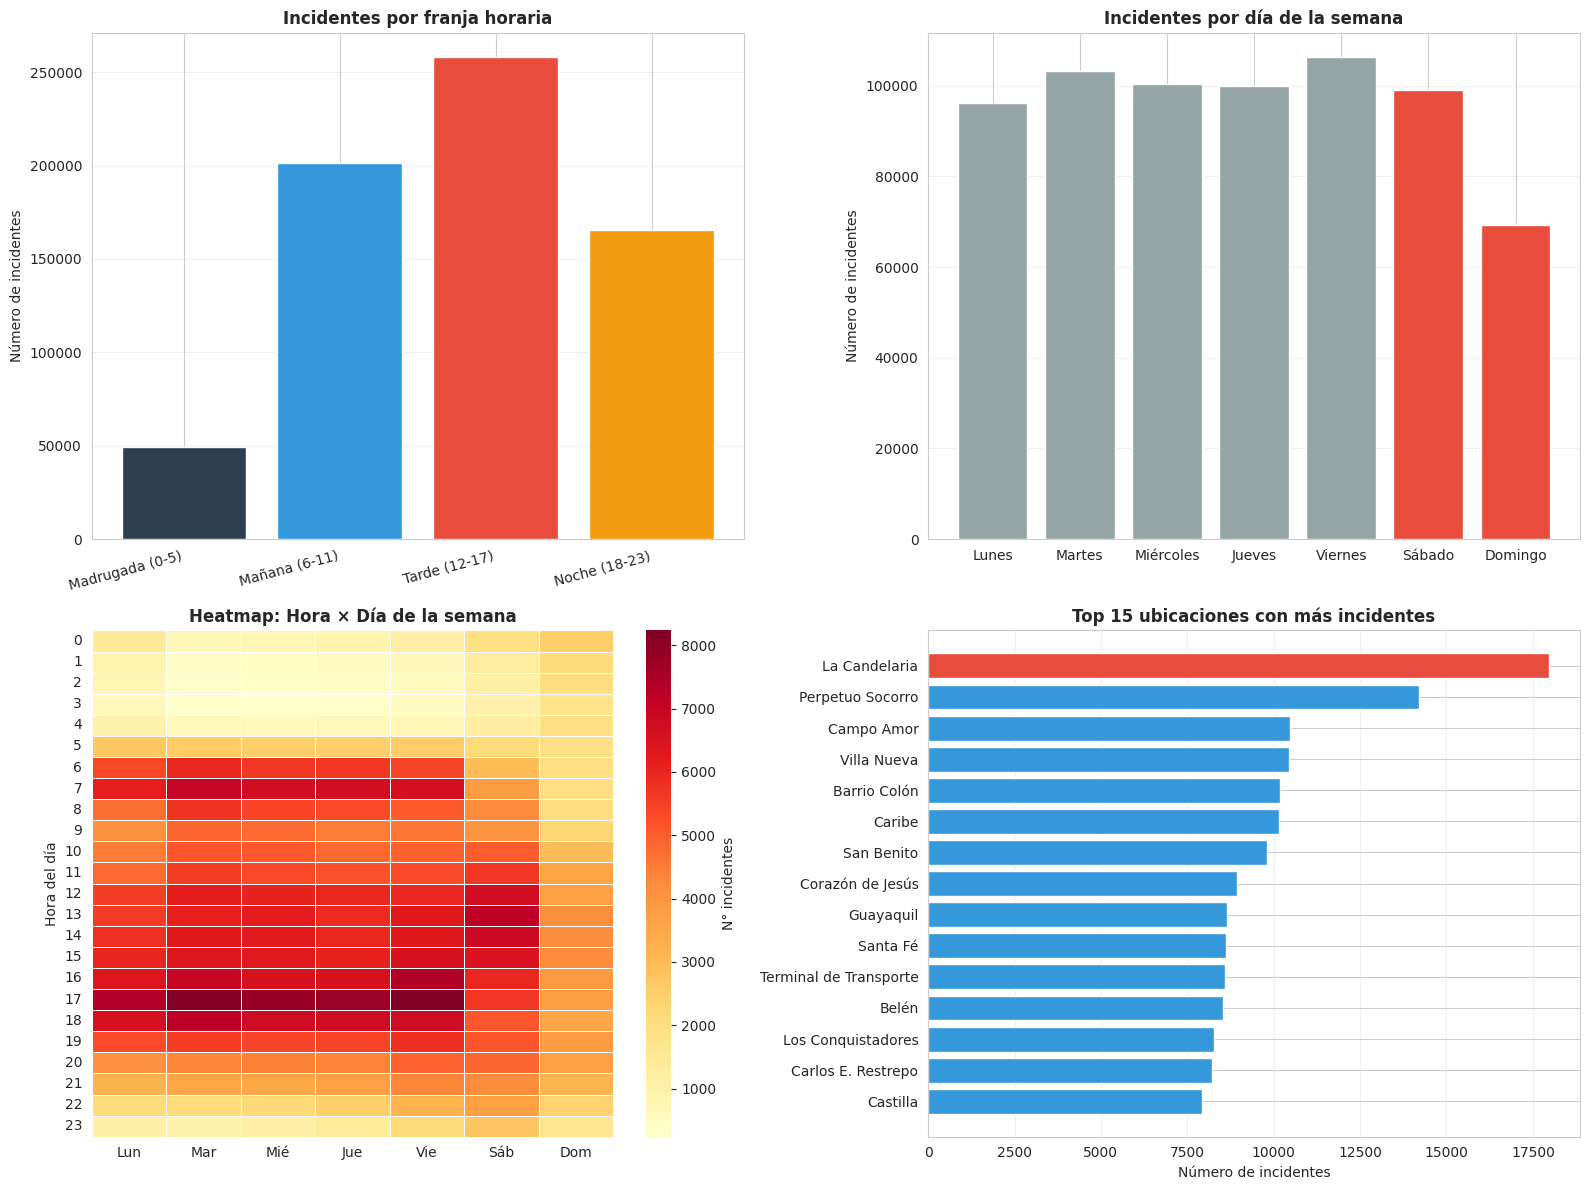

📊 Insights del EDA:
   • Franja con más incidentes: Tarde (12-17) (258,118)
   • Día con más incidentes: Viernes (106,325)
   • Ubicación con más incidentes: La Candelaria (17,965)


6

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

franja_counts = df['FRANJA_HORARIA'].value_counts().sort_index()
colores_franja = ['#2c3e50', '#3498db', '#e74c3c', '#f39c12']
axes[0, 0].bar(range(len(franja_counts)), franja_counts.values, color=colores_franja)
axes[0, 0].set_xticks(range(len(franja_counts)))
axes[0, 0].set_xticklabels(franja_counts.index, rotation=15, ha='right')
axes[0, 0].set_ylabel('Número de incidentes')
axes[0, 0].set_title('Incidentes por franja horaria', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

dia_counts = df['DIA_NOMBRE'].value_counts()
dia_counts = dia_counts.reindex(dias_nombre)
colores_dia = ['#95a5a6' if i < 5 else '#e74c3c' for i in range(7)]
axes[0, 1].bar(dia_counts.index, dia_counts.values, color=colores_dia)
axes[0, 1].set_ylabel('Número de incidentes')
axes[0, 1].set_title('Incidentes por día de la semana', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

heatmap_data = df.pivot_table(
    index='HORA_NUM', columns='DIA_SEMANA',
    values='LLAVE', aggfunc='count'
)
heatmap_data.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[1, 0],
            cbar_kws={'label': 'N° incidentes'}, fmt='.0f', linewidths=0.5)
axes[1, 0].set_title('Heatmap: Hora × Día de la semana', fontweight='bold')
axes[1, 0].set_ylabel('Hora del día')

top_ubicaciones = df['UBICACION_KEY'].value_counts().head(15)
colores_ub = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(top_ubicaciones))]
axes[1, 1].barh(range(len(top_ubicaciones)), top_ubicaciones.values, color=colores_ub)
axes[1, 1].set_yticks(range(len(top_ubicaciones)))
axes[1, 1].set_yticklabels(top_ubicaciones.index)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Número de incidentes')
axes[1, 1].set_title('Top 15 ubicaciones con más incidentes', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Insights del EDA:")
print(f"   • Franja con más incidentes: {franja_counts.idxmax()} ({franja_counts.max():,})")
print(f"   • Día con más incidentes: {dia_counts.idxmax()} ({dia_counts.max():,})")
print(f"   • Ubicación con más incidentes: {top_ubicaciones.index[0]} ({top_ubicaciones.iloc[0]:,})")

del heatmap_data, franja_counts, dia_counts, top_ubicaciones
gc.collect()

---
## Paso 6: Construcción del dataset de modelado

Este es el paso más crítico del proyecto. Transformamos el registro de eventos
en un dataset de clasificación binaria con eventos positivos y negativos.

### Estrategia de creación del target

1. **Agrupación:** Contamos cuántos incidentes ocurrieron en cada combinación de
   `ubicación × día_semana × franja_2h × mes`

2. **Grilla completa:** Generamos un producto cartesiano de todas las combinaciones
   posibles de estos cuatro factores

3. **Merge + bandera:** Unimos la grilla con los conteos reales:
   - Si la combinación tiene conteo > 0 → `HUBO_INCIDENTE = 1`
   - Si la combinación no existe en los datos reales → `HUBO_INCIDENTE = 0`

### Nota sobre el balanceo de clases

La mayoría de los slots espacio-temporales no tendrán incidentes, por lo que las
clases estarán desbalanceadas. Esto se manejará con `class_weight='balanced'`
en los modelos.

In [23]:
print("🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO")
print("=" * 70)

target_agg = df.groupby(
    ['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    observed=False
).agg(
    NUM_INCIDENTES=('LLAVE', 'count'),
    INCIDENTES_FATALES=('GRAVEDAD_INCIDENTE', lambda x: (x == 'MUERTO').sum()),
).reset_index()

print(f"Slots con al menos un incidente: {target_agg.shape[0]:,}")

ubicaciones_unicas = df['UBICACION_KEY'].unique()
dias_unicos = sorted(df['DIA_SEMANA'].unique())
franjas_unicas = sorted(df['FRANJA_2H'].unique())
meses_unicos = sorted(df['MES'].unique())

total_combinaciones = len(ubicaciones_unicas) * len(dias_unicos) * len(franjas_unicas) * len(meses_unicos)
print(f"Dimensiones: {len(ubicaciones_unicas)} ubicaciones × {len(dias_unicos)} días × {len(franjas_unicas)} franjas × {len(meses_unicos)} meses")
print(f"Total combinaciones posibles: {total_combinaciones:,}")

🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO
Slots con al menos un incidente: 405,216
Dimensiones: 402 ubicaciones × 7 días × 12 franjas × 12 meses
Total combinaciones posibles: 405,216


In [24]:
print("⏳ Generando grilla completa de slots espacio-temporales...")

idx_completo = pd.MultiIndex.from_product(
    [ubicaciones_unicas, dias_unicos, franjas_unicas, meses_unicos],
    names=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES']
)

grid_df = pd.DataFrame(index=idx_completo).reset_index()

model_df = pd.merge(
    grid_df, target_agg,
    on=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    how='left'
)

model_df['NUM_INCIDENTES'] = model_df['NUM_INCIDENTES'].fillna(0).astype('int16')
model_df['INCIDENTES_FATALES'] = model_df['INCIDENTES_FATALES'].fillna(0).astype('int16')

model_df['HUBO_INCIDENTE'] = (model_df['NUM_INCIDENTES'] > 0).astype('int8')

print(f"\n✅ Dataset de modelado construido:")
print(f"   Total slots: {model_df.shape[0]:,}")
print(f"   Slots con incidentes: {model_df['HUBO_INCIDENTE'].sum():,} ({model_df['HUBO_INCIDENTE'].mean()*100:.1f}%)")
print(f"   Slots sin incidentes: {(model_df['HUBO_INCIDENTE']==0).sum():,} ({(1-model_df['HUBO_INCIDENTE'].mean())*100:.1f}%)")

del grid_df, target_agg, idx_completo
gc.collect()

⏳ Generando grilla completa de slots espacio-temporales...

✅ Dataset de modelado construido:
   Total slots: 405,216
   Slots con incidentes: 192,945 (47.6%)
   Slots sin incidentes: 212,271 (52.4%)


0

---
## Paso 7: Feature Engineering para el modelo

Creamos features avanzadas para mejorar la capacidad predictiva:

### Features temporales codificadas
- **Codificación cíclica** para día de la semana y mes usando seno/coseno
  - Permite al modelo entender que lunes y domingo son cercanos en el ciclo semanal
- **Hora punto medio** de la franja de 2 horas

### Target Encoding para ubicación
- Reemplaza la ubicación categórica por la tasa de incidentes observada
- **Suavizado bayesiano empírico:** Para ubicaciones con pocos datos, se acerca a la media global
- Esto evita overfitting en ubicaciones con pocas muestras

### Features de interacción
- `INTERACCION_FINDE_NOCHE`: Captura el efecto combinado de fin de semana + horario nocturno

In [25]:
print("⚙️  FEATURE ENGINEERING")
print("=" * 70)

model_df['ES_FIN_SEMANA'] = model_df['DIA_SEMANA'].isin([5, 6]).astype('int8')
model_df['ES_LABORAL'] = (~model_df['DIA_SEMANA'].isin([5, 6])).astype('int8')

model_df['DIA_SEMANA_SIN'] = np.sin(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')
model_df['DIA_SEMANA_COS'] = np.cos(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')

model_df['MES_SIN'] = np.sin(2 * np.pi * model_df['MES'] / 12.0).astype('float32')
model_df['MES_COS'] = np.cos(2 * np.pi * model_df['MES'] / 12.0).astype('float32')

franja_a_hora = {}
for label in labels_2h:
    hora_inicio = int(label.split('-')[0])
    franja_a_hora[label] = hora_inicio + 1
model_df['HORA_PUNTO_MEDIO'] = model_df['FRANJA_2H'].map(franja_a_hora).astype('int8')

print("✅ Features temporales codificadas")

⚙️  FEATURE ENGINEERING
✅ Features temporales codificadas


In [26]:
print("🎯 Calculando Target Encoding para ubicaciones...")

global_incidence_rate = model_df['HUBO_INCIDENTE'].mean()

ubicacion_stats = model_df.groupby('UBICACION_KEY').agg(
    ubicacion_mean=('HUBO_INCIDENTE', 'mean'),
    ubicacion_count=('HUBO_INCIDENTE', 'count'),
    ubicacion_std=('HUBO_INCIDENTE', 'std')
)

m_smooth = 50.0

ubicacion_stats['UBICACION_TARGET_ENC'] = (
    (ubicacion_stats['ubicacion_count'] * ubicacion_stats['ubicacion_mean'] +
     m_smooth * global_incidence_rate) /
    (ubicacion_stats['ubicacion_count'] + m_smooth)
).astype('float32')

ubicacion_stats['UBICACION_LOG_ODDS'] = np.log(
    (ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001) /
    (1 - ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001)
).astype('float32')

model_df = model_df.merge(
    ubicacion_stats[['UBICACION_TARGET_ENC', 'UBICACION_LOG_ODDS']],
    on='UBICACION_KEY', how='left'
)

print(f"✅ Target encoding completado (suavizado m={m_smooth})")

🎯 Calculando Target Encoding para ubicaciones...
✅ Target encoding completado (suavizado m=50.0)


In [27]:
franja_dummies = pd.get_dummies(model_df['FRANJA_2H'], prefix='FRANJA', dtype='int8')
model_df = pd.concat([model_df, franja_dummies], axis=1)

model_df['INTERACCION_FINDE_NOCHE'] = (
    model_df['ES_FIN_SEMANA'] *
    (model_df['HORA_PUNTO_MEDIO'] >= 18).astype('int8')
).astype('int8')

print(f"✅ Features de interacción creadas")
print(f"\n📊 Dataset final para modelado:")
print(f"   Filas: {model_df.shape[0]:,}")
print(f"   Columnas: {model_df.shape[1]}")
print(f"   Memoria: {model_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del franja_dummies
gc.collect()

✅ Features de interacción creadas

📊 Dataset final para modelado:
   Filas: 405,216
   Columnas: 29
   Memoria: 66.7 MB


0

---
## Paso 8: Preparación de datos para entrenamiento

Separamos features y target, y dividimos en conjuntos de entrenamiento y prueba.
Usamos estratificación para mantener la proporción de clases en ambos conjuntos.

In [28]:
print("🎯 PREPARACIÓN PARA ENTRENAMIENTO")
print("=" * 70)

columnas_excluir = [
    'UBICACION_KEY', 'FRANJA_2H', 'NUM_INCIDENTES',
    'INCIDENTES_FATALES', 'HUBO_INCIDENTE'
]

feature_cols = [col for col in model_df.columns if col not in columnas_excluir]

X = model_df[feature_cols].copy()
y = model_df['HUBO_INCIDENTE'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} muestras (positivos: {y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras (positivos: {y_test.mean()*100:.1f}%)")

del X, y
gc.collect()

🎯 PREPARACIÓN PARA ENTRENAMIENTO
Features: 24
Train: 324,172 muestras (positivos: 47.6%)
Test:  81,044 muestras (positivos: 47.6%)


0

---
## Paso 9: Entrenamiento de modelos

Entrenamos tres modelos de complejidad creciente:

| Modelo | Ventaja |
|--------|---------|
| **Regresión Logística** | Baseline interpretable, coeficientes explicables |
| **Random Forest** | Captura interacciones no lineales, robusto |
| **XGBoost** | Mejor performance esperada, gradient boosting |

Todos usan balanceo de clases para manejar el desbalance natural de los datos.

In [29]:
print("🤖 ENTRENAMIENTO DE MODELOS")
print("=" * 70)

resultados = {}

print("\n📈 Entrenando Regresión Logística (baseline)...")
logreg = LogisticRegression(
    max_iter=2000, class_weight='balanced', C=0.1,
    random_state=42, solver='saga', n_jobs=-1
)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

resultados['Logistic Regression'] = {
    'y_pred': y_pred_logreg, 'y_proba': y_proba_logreg, 'modelo': logreg
}
print("   ✅ Completado")

🤖 ENTRENAMIENTO DE MODELOS

📈 Entrenando Regresión Logística (baseline)...
   ✅ Completado


In [30]:
print("\n🌲 Entrenando Random Forest...")

n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
scale_pos_weight_rf = n_neg / n_pos

rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=50,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

resultados['Random Forest'] = {
    'y_pred': y_pred_rf, 'y_proba': y_proba_rf, 'modelo': rf
}
print("   ✅ Completado")


🌲 Entrenando Random Forest...
   ✅ Completado


In [31]:
print("\n🚀 Entrenando XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_rf,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

resultados['XGBoost'] = {
    'y_pred': y_pred_xgb, 'y_proba': y_proba_xgb, 'modelo': xgb_model
}
print("   ✅ Completado")

print("\n" + "=" * 70)
print("✅ Todos los modelos entrenados correctamente")


🚀 Entrenando XGBoost...
   ✅ Completado

✅ Todos los modelos entrenados correctamente


---
## Paso 10: Evaluación y comparación de modelos

Comparamos los tres modelos usando:
- **Accuracy:** Proporción de predicciones correctas
- **Precision (clase 1):** De los que predice incidente, ¿cuántos realmente lo tuvieron?
- **Recall (clase 1):** De los que realmente tuvieron incidente, ¿cuántos detectó?
- **F1-score:** Media armónica de precision y recall
- **ROC AUC:** Capacidad de discriminar entre clases (independiente del umbral)

El **ROC AUC** es nuestra métrica principal porque no depende del umbral de clasificación.

In [32]:
print("📊 EVALUACIÓN DE MODELOS")
print("=" * 70)

metricas_dict = {}

for nombre, res in resultados.items():
    y_pred = res['y_pred']
    y_proba = res['y_proba']

    report = classification_report(
        y_test, y_pred,
        target_names=['Sin incidente', 'Con incidente'],
        output_dict=True
    )
    roc_auc = roc_auc_score(y_test, y_proba)

    metricas_dict[nombre] = {
        'Accuracy': report['accuracy'],
        'Precision (clase 1)': report['Con incidente']['precision'],
        'Recall (clase 1)': report['Con incidente']['recall'],
        'F1-score (clase 1)': report['Con incidente']['f1-score'],
        'ROC AUC': roc_auc
    }

    print(f"\n{'─' * 70}")
    print(f"📈 {nombre}")
    print(f"{'─' * 70}")
    print(f"  Accuracy:           {report['accuracy']:.4f}")
    print(f"  Precision (clase 1): {report['Con incidente']['precision']:.4f}")
    print(f"  Recall (clase 1):    {report['Con incidente']['recall']:.4f}")
    print(f"  F1-score (clase 1):  {report['Con incidente']['f1-score']:.4f}")
    print(f"  ROC AUC:            {roc_auc:.4f}")

mejor_modelo_nombre = max(metricas_dict, key=lambda k: metricas_dict[k]['ROC AUC'])
print(f"\n{'=' * 70}")
print(f"🏆 Mejor modelo: {mejor_modelo_nombre} (ROC AUC: {metricas_dict[mejor_modelo_nombre]['ROC AUC']:.4f})")

📊 EVALUACIÓN DE MODELOS

──────────────────────────────────────────────────────────────────────
📈 Logistic Regression
──────────────────────────────────────────────────────────────────────
  Accuracy:           0.8375
  Precision (clase 1): 0.8100
  Recall (clase 1):    0.8607
  F1-score (clase 1):  0.8346
  ROC AUC:            0.9203

──────────────────────────────────────────────────────────────────────
📈 Random Forest
──────────────────────────────────────────────────────────────────────
  Accuracy:           0.8441
  Precision (clase 1): 0.8253
  Recall (clase 1):    0.8532
  F1-score (clase 1):  0.8390
  ROC AUC:            0.9250

──────────────────────────────────────────────────────────────────────
📈 XGBoost
──────────────────────────────────────────────────────────────────────
  Accuracy:           0.8451
  Precision (clase 1): 0.8273
  Recall (clase 1):    0.8527
  F1-score (clase 1):  0.8398
  ROC AUC:            0.9256

🏆 Mejor modelo: XGBoost (ROC AUC: 0.9256)


---
## Paso 10.2: Matrices de Confusión — Visualización

Cada modelo produce una **matriz de confusión** que nos muestra exactamente
dónde acierta y dónde falla.

### ¿Cómo interpretar una matriz de confusión?

| | Predice: NO incidente | Predice: SÍ incidente |
|---|---|---|
| **Real: NO incidente** | ✅ Verdadero Negativo (VN) | ❌ Falso Positivo (FP) — *falsa alarma* |
| **Real: SÍ incidente** | ❌ Falso Negativo (FN) — *no detectado* | ✅ Verdadero Positivo (VP) — *detección correcta* |

### ¿Qué buscamos en este problema?

- **Diagonal principal** (↘️): Valores ALTOS → predicciones correctas
- **Falsos Negativos** (↙️): Los MÁS PELIGROSOS. Son incidentes reales que el modelo
  no detectó. En seguridad vial, queremos MINIMIZAR este número.
- **Falsos Positivos** (↗️): Falsas alarmas. Menos graves, pero si son muchas
  el modelo pierde utilidad práctica.

### Comparación visual

Mostramos las 3 matrices lado a lado para identificar rápidamente
qué modelo equilibra mejor la detección de incidentes reales sin
generar demasiadas falsas alarmas.

📊 MATRICES DE CONFUSIÓN


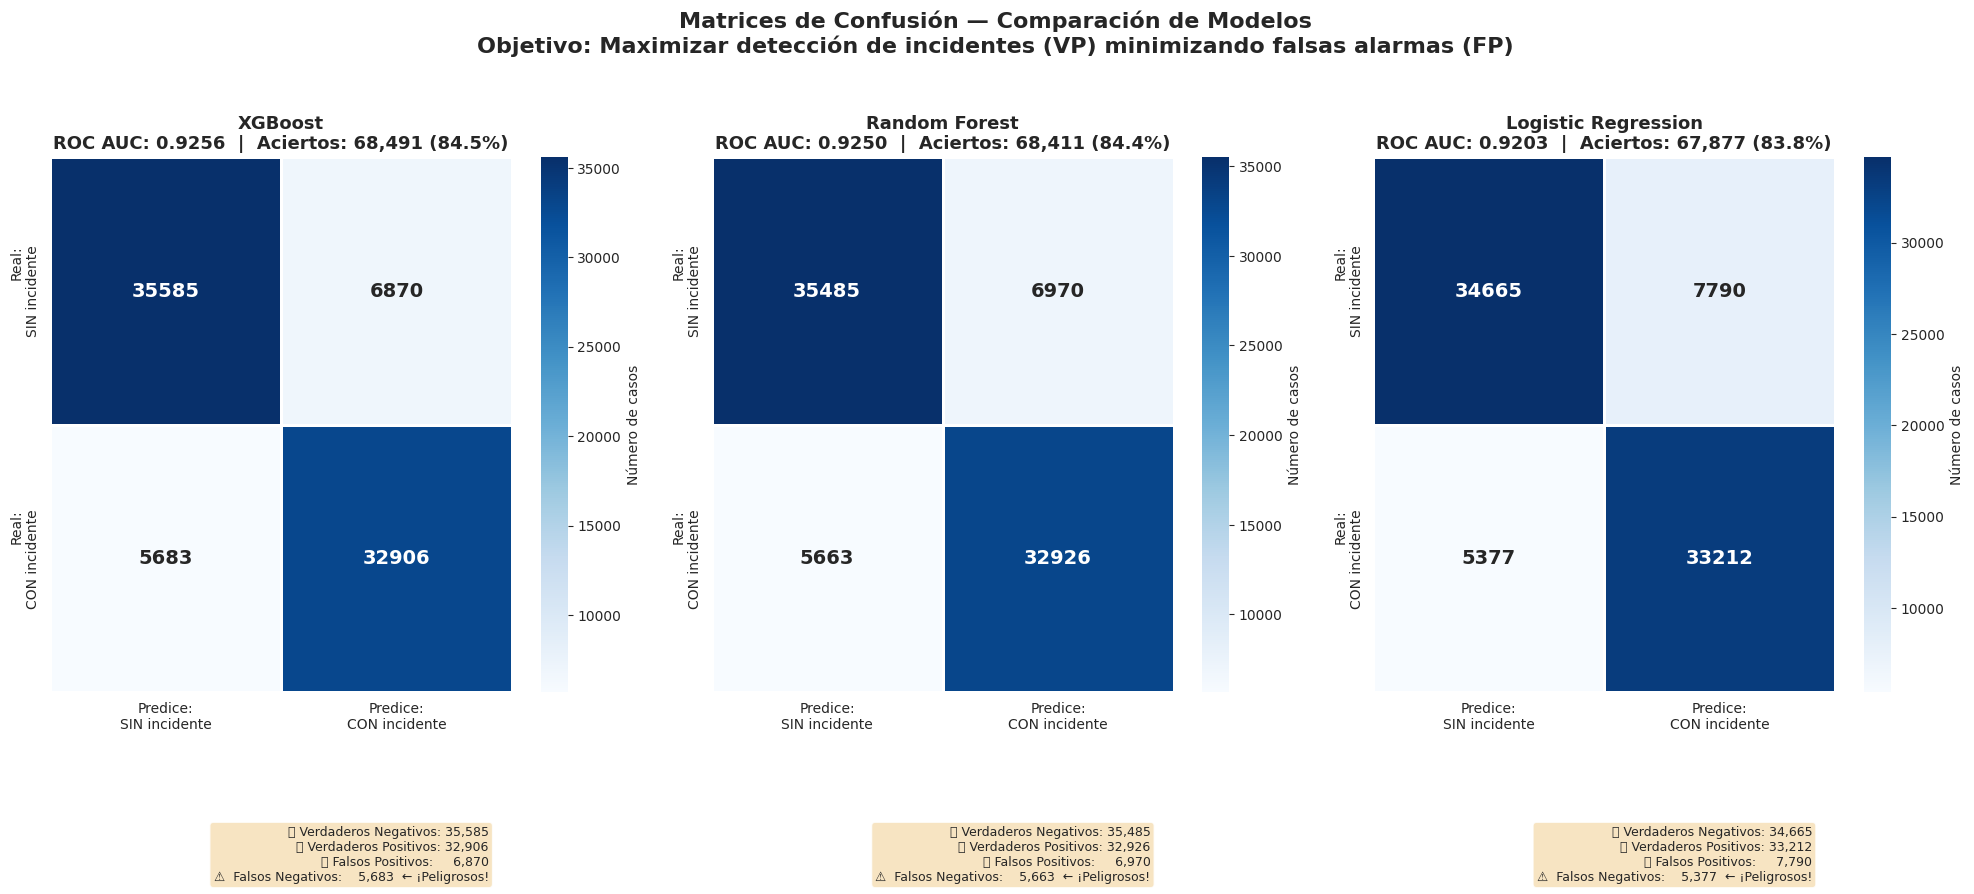


📋 RESUMEN DE MATRICES:

  XGBoost:
    VN=  35,585  FP=   6,870  FN=   5,683  VP=  32,906
    Tasa detección: 85.3%  |  Tasa falsa alarma: 16.2%

  Random Forest:
    VN=  35,485  FP=   6,970  FN=   5,663  VP=  32,926
    Tasa detección: 85.3%  |  Tasa falsa alarma: 16.4%

  Logistic Regression:
    VN=  34,665  FP=   7,790  FN=   5,377  VP=  33,212
    Tasa detección: 86.1%  |  Tasa falsa alarma: 18.3%



In [47]:
print("📊 MATRICES DE CONFUSIÓN")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

modelos_ordenados = sorted(
    metricas_dict.items(),
    key=lambda x: x[1]['ROC AUC'],
    reverse=True
)

for i, (nombre, metricas) in enumerate(modelos_ordenados):
    res = resultados[nombre]
    y_pred = res['y_pred']
    roc_auc = metricas['ROC AUC']

    cm = confusion_matrix(y_test, y_pred)
    vn, fp, fn, vp = cm.ravel()

    total = vn + fp + fn + vp
    aciertos = vn + vp
    fallos = fp + fn

    row = i // 3
    col = i % 3

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[row, col],
        xticklabels=['Predice:\nSIN incidente', 'Predice:\nCON incidente'],
        yticklabels=['Real:\nSIN incidente', 'Real:\nCON incidente'],
        cbar_kws={'label': 'Número de casos'},
        linewidths=1,
        linecolor='white',
        annot_kws={'fontsize': 14, 'fontweight': 'bold'}
    )

    axes[row, col].set_title(
        f'{nombre}\n'
        f'ROC AUC: {roc_auc:.4f}  |  '
        f'Aciertos: {aciertos:,} ({aciertos/total*100:.1f}%)',
        fontweight='bold',
        fontsize=13
    )

    texto_resumen = (
        f'✅ Verdaderos Negativos: {vn:,}\n'
        f'✅ Verdaderos Positivos: {vp:,}\n'
        f'❌ Falsos Positivos:     {fp:,}\n'
        f'⚠️  Falsos Negativos:    {fn:,}  ← ¡Peligrosos!'
    )
    axes[row, col].text(
        0.95, -0.25, texto_resumen,
        transform=axes[row, col].transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )

# Ocultar ejes vacíos si hay menos de 6 modelos
for j in range(len(modelos_ordenados), 6):
    row = j // 3
    col = j % 3
    axes[row, col].set_visible(False)

plt.suptitle(
    'Matrices de Confusión — Comparación de Modelos\n'
    'Objetivo: Maximizar detección de incidentes (VP) minimizando falsas alarmas (FP)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

print("\n📋 RESUMEN DE MATRICES:\n")
for nombre, metricas in modelos_ordenados:
    res = resultados[nombre]
    cm = confusion_matrix(y_test, res['y_pred'])
    vn, fp, fn, vp = cm.ravel()
    print(f"  {nombre}:")
    print(f"    VN={vn:>8,}  FP={fp:>8,}  FN={fn:>8,}  VP={vp:>8,}")
    print(f"    Tasa detección: {vp/(vp+fn)*100:.1f}%  |  Tasa falsa alarma: {fp/(fp+vn)*100:.1f}%")
    print()

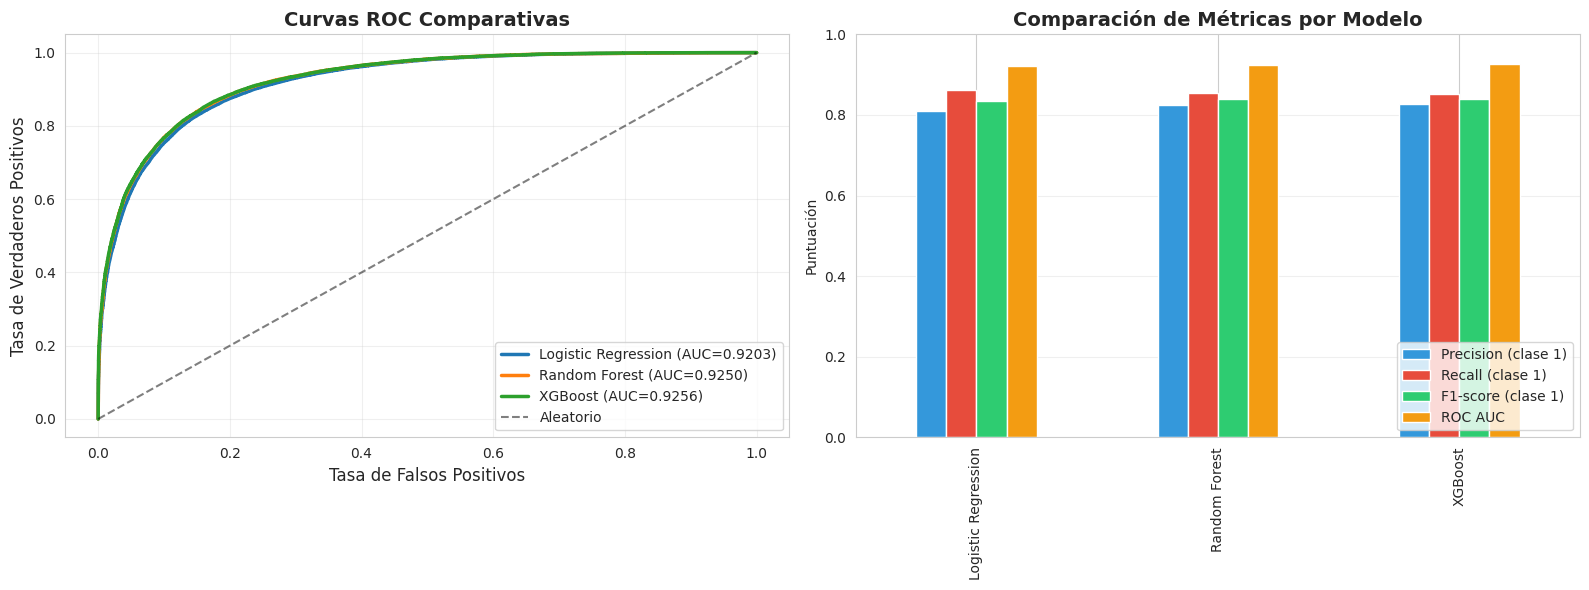

In [34]:
fig, axes_roc = plt.subplots(1, 2, figsize=(16, 6))

for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes_roc[0].plot(fpr, tpr, linewidth=2.5,
                     label=f"{nombre} (AUC={metricas_dict[nombre]['ROC AUC']:.4f})")

axes_roc[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
axes_roc[0].set_xlabel('Tasa de Falsos Positivos', fontsize=12)
axes_roc[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
axes_roc[0].set_title('Curvas ROC Comparativas', fontsize=14, fontweight='bold')
axes_roc[0].legend(loc='lower right')
axes_roc[0].grid(alpha=0.3)

metricas_comparacion = pd.DataFrame(metricas_dict).T
colores_bar = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
metricas_comparacion[['Precision (clase 1)', 'Recall (clase 1)', 'F1-score (clase 1)', 'ROC AUC']].plot(
    kind='bar', ax=axes_roc[1], color=colores_bar
)
axes_roc[1].set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
axes_roc[1].set_ylabel('Puntuación')
axes_roc[1].set_ylim(0, 1)
axes_roc[1].legend(loc='lower right')
axes_roc[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Paso 11: Importancia de Features

Analizamos qué variables contribuyen más a la predicción del modelo XGBoost.
Esto nos ayuda a entender los factores de riesgo más relevantes.

🔍 IMPORTANCIA DE FEATURES — XGBoost

Top 20 features más importantes:

   UBICACION_TARGET_ENC                          → 0.2127
   UBICACION_LOG_ODDS                            → 0.1881
   HORA_PUNTO_MEDIO                              → 0.1244
   FRANJA_00-02h                                 → 0.1077
   FRANJA_02-04h                                 → 0.0935
   FRANJA_04-06h                                 → 0.0525
   FRANJA_22-24h                                 → 0.0506
   ES_LABORAL                                    → 0.0471
   ES_FIN_SEMANA                                 → 0.0200
   DIA_SEMANA                                    → 0.0160
   DIA_SEMANA_SIN                                → 0.0109
   FRANJA_16-18h                                 → 0.0093
   FRANJA_18-20h                                 → 0.0083
   FRANJA_08-10h                                 → 0.0069
   FRANJA_14-16h                                 → 0.0065
   FRANJA_06-08h                                 → 0.0064
 

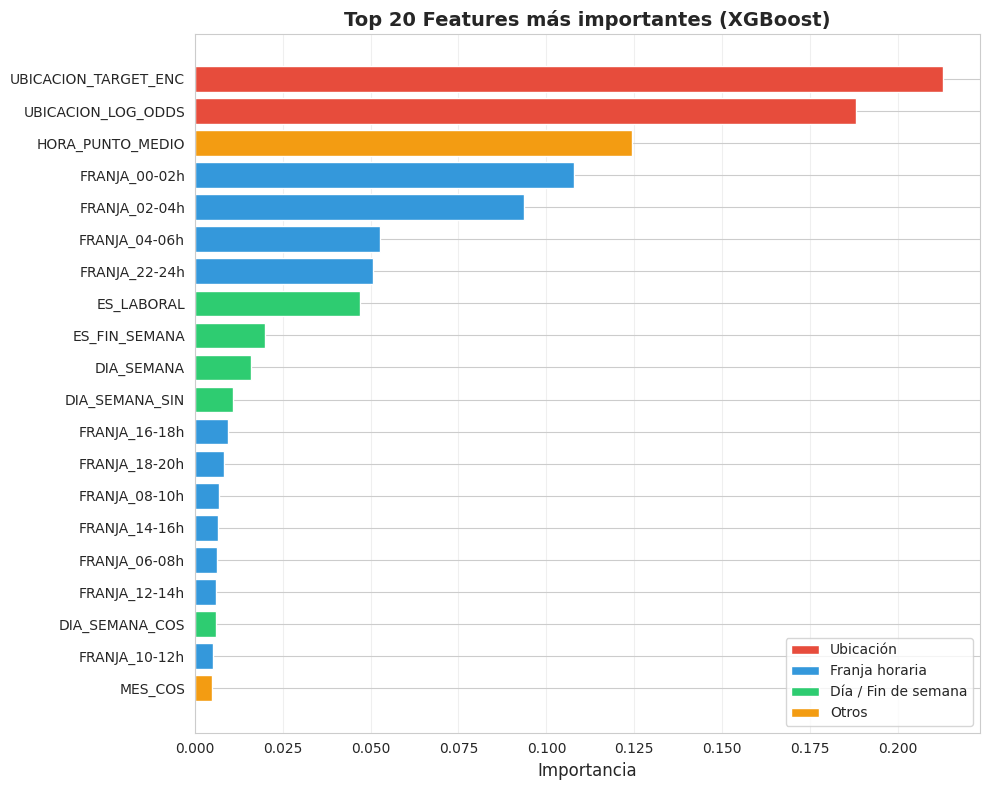

In [35]:
print("🔍 IMPORTANCIA DE FEATURES — XGBoost")
print("=" * 70)

importancia = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 features más importantes:\n")
for i, row in importancia.head(20).iterrows():
    print(f"   {row['feature']:<45s} → {row['importance']:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))

top_20 = importancia.head(20).iloc[::-1]
colores_imp = []
for f in top_20['feature']:
    if 'UBICACION' in f:
        colores_imp.append('#e74c3c')
    elif 'FRANJA' in f:
        colores_imp.append('#3498db')
    elif 'DIA' in f or 'FIN_SEMANA' in f or 'LABORAL' in f:
        colores_imp.append('#2ecc71')
    else:
        colores_imp.append('#f39c12')

ax.barh(range(len(top_20)), top_20['importance'], color=colores_imp, edgecolor='white')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 20 Features más importantes (XGBoost)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Ubicación'),
    Patch(facecolor='#3498db', label='Franja horaria'),
    Patch(facecolor='#2ecc71', label='Día / Fin de semana'),
    Patch(facecolor='#f39c12', label='Otros')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

---
## Paso 12: Sistema de Predicción de Riesgo

Esta es la pieza final del proyecto: una función que recibe una **ubicación**,
un **día de la semana** y una **hora**, y devuelve la **probabilidad estimada**
de que ocurra al menos un accidente.

### Ejemplo de uso:
```python
riesgo = predecir_riesgo('Laureles Estadio', 'Viernes', 23)
# → 0.73  (73% de probabilidad)
```

La función reconstruye todo el pipeline de feature engineering para la nueva
muestra antes de pasarla al modelo.

In [36]:
def predecir_riesgo(ubicacion, dia_semana_nombre, hora, modelo,
                    feature_cols_ref, ubicacion_stats_ref,
                    m_smooth_ref, global_rate_ref):
    """
    Predice la probabilidad de que ocurra al menos un accidente.

    Parámetros:
    - ubicacion: str, nombre del barrio o comuna
    - dia_semana_nombre: str, 'Lunes' a 'Domingo'
    - hora: int (0-23) o str 'HH:MM'
    - modelo: modelo entrenado (XGBoost, RandomForest, etc.)

    Retorna:
    - probabilidad: float entre 0 y 1
    """

    if isinstance(hora, str):
        hora_num = int(hora.split(':')[0])
    else:
        hora_num = int(hora)

    dias_map = {
        'lunes': 0, 'martes': 1, 'miércoles': 2, 'miercoles': 2,
        'jueves': 3, 'viernes': 4, 'sábado': 5, 'sabado': 5, 'domingo': 6
    }
    dia_num = dias_map.get(dia_semana_nombre.lower(), 0)

    franja_idx = min(hora_num // 2, 11)
    franja_label = f'{franja_idx*2:02d}-{(franja_idx+1)*2:02d}h'

    es_fin_semana = 1 if dia_num >= 5 else 0
    es_laboral = 1 - es_fin_semana
    dia_sin = np.sin(2 * np.pi * dia_num / 7.0)
    dia_cos = np.cos(2 * np.pi * dia_num / 7.0)

    mes = 6
    mes_sin = np.sin(2 * np.pi * mes / 12.0)
    mes_cos = np.cos(2 * np.pi * mes / 12.0)

    hora_punto_medio = franja_idx * 2 + 1

    if ubicacion in ubicacion_stats_ref.index:
        ubicacion_target_enc = ubicacion_stats_ref.loc[ubicacion, 'UBICACION_TARGET_ENC']
        ubicacion_log_odds = ubicacion_stats_ref.loc[ubicacion, 'UBICACION_LOG_ODDS']
    else:
        ubicacion_target_enc = global_rate_ref
        ubicacion_log_odds = np.log((global_rate_ref + 0.001) / (1 - global_rate_ref + 0.001))

    interaccion_finde_noche = es_fin_semana * (1 if hora_num >= 18 else 0)

    input_dict = {
        'DIA_SEMANA': dia_num,
        'MES': mes,
        'ES_FIN_SEMANA': es_fin_semana,
        'ES_LABORAL': es_laboral,
        'DIA_SEMANA_SIN': dia_sin,
        'DIA_SEMANA_COS': dia_cos,
        'MES_SIN': mes_sin,
        'MES_COS': mes_cos,
        'HORA_PUNTO_MEDIO': hora_punto_medio,
        'UBICACION_TARGET_ENC': ubicacion_target_enc,
        'UBICACION_LOG_ODDS': ubicacion_log_odds,
        'INTERACCION_FINDE_NOCHE': interaccion_finde_noche
    }

    for i in range(12):
        franja_col = f'FRANJA_{i*2:02d}-{(i+1)*2:02d}h'
        input_dict[franja_col] = 1 if i == franja_idx else 0

    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=feature_cols_ref, fill_value=0)

    probabilidad = modelo.predict_proba(input_df)[:, 1][0]
    return probabilidad

print("✅ Función de predicción definida")

✅ Función de predicción definida


In [53]:
print("🧪 PRUEBAS DEL SISTEMA DE PREDICCIÓN")
print("=" * 70)

pruebas = [
    ('Laureles Estadio', 'Viernes', 23, '🌙 Noche de viernes en zona de rumba'),
    ('Corregimiento de San Cristóbal', 'Martes', 4, '🌅 Madrugada en zona rural'),
    ('La Candelaria', 'Domingo', 14, '☀️ Tarde de domingo en el centro'),
    ('El Poblado', 'Sábado', 22, '🌃 Sábado noche en zona exclusiva'),
    ('Corregimiento de San Antonio de Prado', 'Sábado', 20, '🌃 tranqui'),
]

for ubicacion, dia, hora, descripcion in pruebas:
    prob = predecir_riesgo(
        ubicacion, dia, hora, xgb_model, feature_cols,
        ubicacion_stats, m_smooth, global_incidence_rate
    )

    barra = '☠️' * int(prob * 40) + '❤️' * (40 - int(prob * 40))
    print(f"\n📍 {ubicacion}")
    print(f"   {dia} a las {hora}:00h — {descripcion}")
    print(f"   Riesgo: [{barra}] {prob:.1%}")

print("\n" + "=" * 70)
print("✅ Sistema de predicción funcionando correctamente")

🧪 PRUEBAS DEL SISTEMA DE PREDICCIÓN

📍 Laureles Estadio
   Viernes a las 23:00h — 🌙 Noche de viernes en zona de rumba
   Riesgo: [☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️] 72.8%

📍 Corregimiento de San Cristóbal
   Martes a las 4:00h — 🌅 Madrugada en zona rural
   Riesgo: [☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️] 46.2%

📍 La Candelaria
   Domingo a las 14:00h — ☀️ Tarde de domingo en el centro
   Riesgo: [☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️❤️] 99.9%

📍 El Poblado
   Sábado a las 22:00h — 🌃 Sábado noche en zona exclusiva
   Riesgo: [☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️❤️] 98.9%

📍 Corregimiento de San Antonio de Prado
   Sábado a las 20:00h — 🌃 tranqui
   Riesgo: [☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️☠️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️] 55.2%

✅ Sistema de predicción funcionando correctamente


---
## Paso 13: Mapa de Riesgo

Visualizamos la matriz de riesgo promedio por día de la semana y franja horaria.
Esto permite identificar visualmente los patrones de mayor siniestralidad.

🗺️  MAPA DE RIESGO POR DÍA Y FRANJA HORARIA


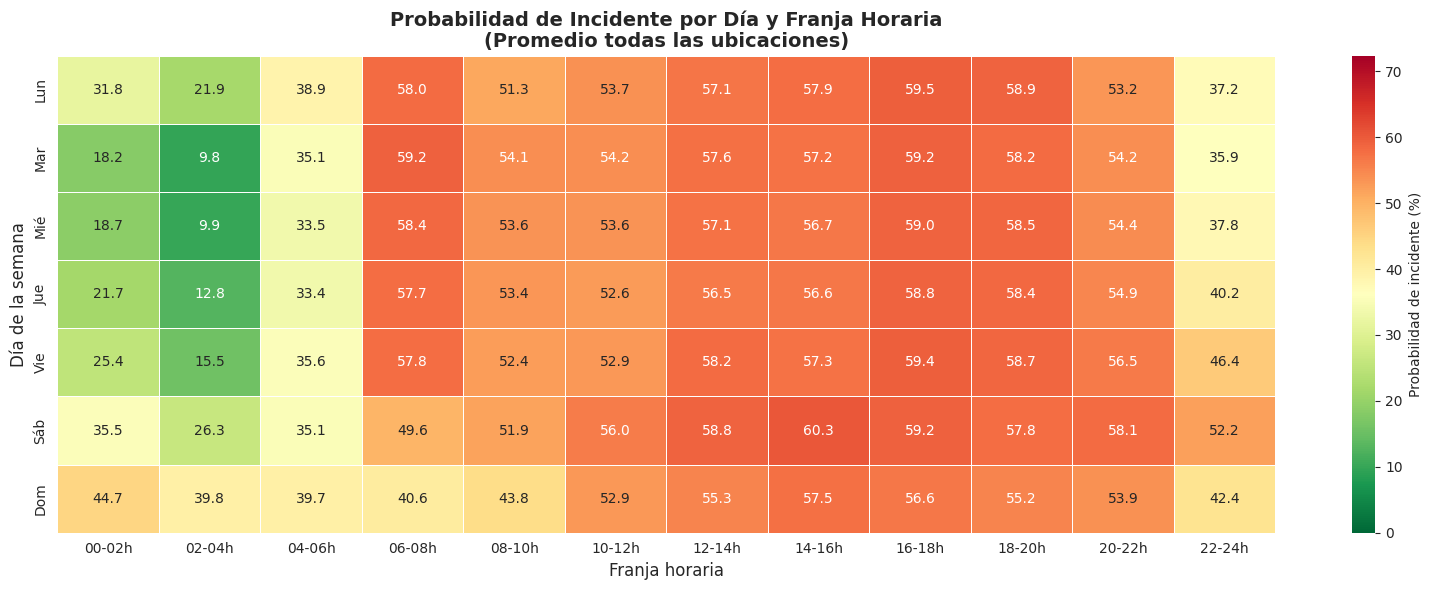

23260

In [38]:
print("🗺️  MAPA DE RIESGO POR DÍA Y FRANJA HORARIA")
print("=" * 70)

riesgo_promedio = model_df.groupby(['DIA_SEMANA', 'FRANJA_2H'])['HUBO_INCIDENTE'].mean().unstack()
riesgo_promedio.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(riesgo_promedio * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Probabilidad de incidente (%)'},
            vmin=0, vmax=riesgo_promedio.max().max() * 100 * 1.2,
            linewidths=0.5, linecolor='white')

ax.set_title('Probabilidad de Incidente por Día y Franja Horaria\n(Promedio todas las ubicaciones)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Día de la semana', fontsize=12)
ax.set_xlabel('Franja horaria', fontsize=12)

plt.tight_layout()
plt.show()

del riesgo_promedio
gc.collect()

---
## Paso 14: Resumen y Conclusiones

Resumen ejecutivo del proyecto, métricas clave y recomendaciones para próximos pasos.

In [39]:
print("\n" + "=" * 70)
print("📋 RESUMEN Y CONCLUSIONES")
print("=" * 70)

print(f"""
✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: ~700,000
   • Registros después de limpieza (eliminación de nulos): {len(df):,}
   • Registros eliminados: {registros_iniciales - len(df):,}
   • Ubicaciones únicas finales: {df['UBICACION_KEY'].nunique()}
   • Período: {df['AÑO'].min()} - {df['AÑO'].max()}

🎯 MODELO FINAL:
   • Mejor modelo: {mejor_modelo_nombre}
   • ROC AUC: {metricas_dict[mejor_modelo_nombre]['ROC AUC']:.4f}
   • Features principales: ubicación (target encoding), franja horaria, día de la semana

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existen patrones estacionales que el modelo captura
   4. El target encoding de ubicación permite manejar eficientemente
      ubicaciones con diferentes volúmenes de datos

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Añadir features externas: clima, tráfico, eventos especiales
   2. Implementar modelo de series temporales por ubicación
   3. Segmentar por tipo de incidente (fatal vs no fatal)
   4. Exportar el modelo para uso en aplicación de predicción en tiempo real
""")

print("=" * 70)
print("🎉 Notebook ejecutado completamente")
print("=" * 70)


📋 RESUMEN Y CONCLUSIONES

✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: ~700,000
   • Registros después de limpieza (eliminación de nulos): 674,394
   • Registros eliminados: 28,146
   • Ubicaciones únicas finales: 402
   • Período: 2008 - 2025

🎯 MODELO FINAL:
   • Mejor modelo: XGBoost
   • ROC AUC: 0.9256
   • Features principales: ubicación (target encoding), franja horaria, día de la semana

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existen patrones estacionales que el modelo captura
   4. El target encoding de ubicación permite manejar eficientemente
      ubicaciones con diferentes volúmenes de datos

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Añadir features externas: clima, tráfico, eventos especiales
   2. Implementar modelo de series temporales por ubicación
   3. Segmentar por tipo de incidente (fatal vs no fatal)
   4. Exporta